In [124]:
import pandas as pd

df = pd.read_csv('aice_day13_customer_churn.csv')

df.head()

,customer_id,signup_date,age,monthly_fee,tenure_months,support_calls,contract_type,payment_method,region,avg_usage_hours,late_payments,churn
0,CUST_1001,2022-08-17,50.0,69.51,47,2,one_year,card,Gwangju,7.54,0,0
1,CUST_1002,2024-10-31,28.0,51.65,21,1,monthly,cash,Gwangju,2.22,0,0
2,CUST_1003,2022-11-23,37.0,49.72,44,4,monthly,card,Daejeon,8.34,3,0
3,CUST_1004,2022-03-30,39.0,42.41,52,3,monthly,mobile,Gwangju,4.52,1,0
4,CUST_1005,2023-08-16,64.0,63.35,35,3,monthly,NaN,Busan,3.56,0,0


In [125]:
df.isnull().sum()

customer_id         0
signup_date         0
age                14
monthly_fee         0
tenure_months       0
support_calls       0
contract_type       0
payment_method     12
region              0
avg_usage_hours    13
late_payments       0
churn               0
dtype: int64

In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      325 non-null    str    
 1   signup_date      325 non-null    str    
 2   age              311 non-null    float64
 3   monthly_fee      325 non-null    float64
 4   tenure_months    325 non-null    int64  
 5   support_calls    325 non-null    int64  
 6   contract_type    325 non-null    str    
 7   payment_method   313 non-null    str    
 8   region           325 non-null    str    
 9   avg_usage_hours  312 non-null    float64
 10  late_payments    325 non-null    int64  
 11  churn            325 non-null    int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 30.6 KB


In [127]:
df.describe()

,age,monthly_fee,tenure_months,support_calls,avg_usage_hours,late_payments,churn
count,311.000000,325.000000,325.000000,325.000000,312.000000,325.000000,325.000000
mean,39.971061,70.106062,32.480000,2.095385,4.771122,0.876923,0.129231
std,11.874986,26.690415,11.880984,2.375312,1.764231,1.016950,0.335972
min,18.000000,21.800000,12.000000,0.000000,0.700000,0.000000,0.000000
25%,32.000000,54.130000,22.000000,0.000000,3.642500,0.000000,0.000000
50%,40.000000,67.120000,32.000000,2.000000,4.520000,1.000000,0.000000
75%,48.000000,81.440000,43.000000,3.000000,5.800000,2.000000,0.000000
max,74.000000,258.530000,54.000000,21.000000,12.140000,4.000000,1.000000


In [128]:
# 중복값 제거 
df.duplicated().sum()

df = df.drop_duplicates()

In [129]:
# 이상치 제거 
q1 = df['monthly_fee'].quantile(0.25)
q3 = df['monthly_fee'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print(q1, q3)
print(lower, upper)
df.shape

53.97 81.125
13.237499999999997 121.8575


(320, 12)

In [130]:
# 이상치가 아닌 값들만 df에 담음
df = df[(df['monthly_fee']>=lower) & (df['monthly_fee']<=upper)]
df.shape

(313, 12)

In [131]:
q1 = df['support_calls'].quantile(0.25)
q3 = df['support_calls'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# -가 나온것은 iqr 공식이 계산한 하한선이 음수가 된 것
print(q1, q3)
print(lower, upper)
df['support_calls'].shape

0.0 3.0
-4.5 7.5


(313,)

In [132]:
# 이상치 확인 
df[(df['support_calls'] < lower) | (df['support_calls'] > upper)]

# 이상치 제거
df = df[(df['support_calls'] >= lower) & (df['support_calls'] <= upper)]
df['support_calls'].shape

(310,)

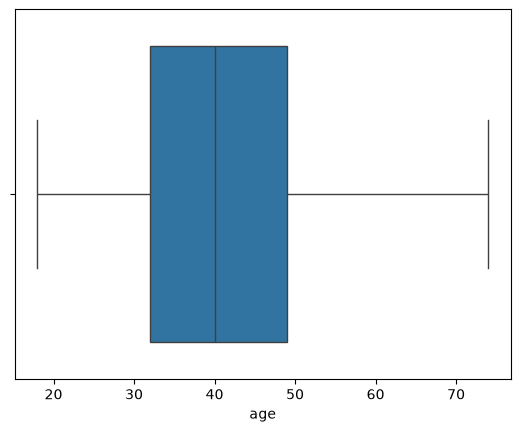

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns

# 중앙값 사용
plt.figure()
sns.boxplot(data=df, x='age')
plt.show()

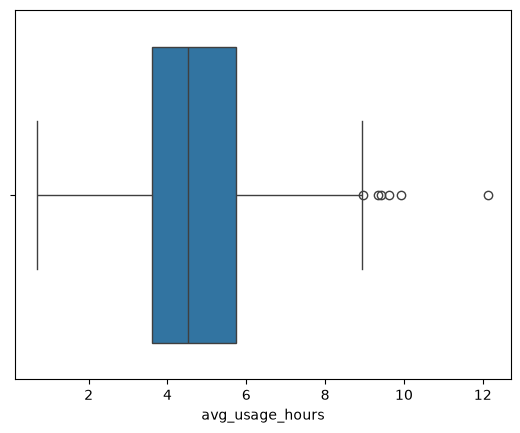

In [134]:
plt.figure()
sns.boxplot(data=df, x='avg_usage_hours')
plt.show()

In [135]:
# 수치형 결측치 처리 
df['age'] = df['age'].fillna(df['age'].median())
df['avg_usage_hours'] = df['avg_usage_hours'].fillna(df['avg_usage_hours'].median())

# 범주형 결측치 처리 
df['payment_method'] = df['payment_method'].fillna(df['payment_method'].mode()[0])

In [136]:
df.isnull().sum()

customer_id        0
signup_date        0
age                0
monthly_fee        0
tenure_months      0
support_calls      0
contract_type      0
payment_method     0
region             0
avg_usage_hours    0
late_payments      0
churn              0
dtype: int64

In [137]:
df['signup_date'] = pd.to_datetime(df['signup_date'])

In [138]:
df.info()

<class 'pandas.DataFrame'>
Index: 310 entries, 0 to 319
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   customer_id      310 non-null    str           
 1   signup_date      310 non-null    datetime64[us]
 2   age              310 non-null    float64       
 3   monthly_fee      310 non-null    float64       
 4   tenure_months    310 non-null    int64         
 5   support_calls    310 non-null    int64         
 6   contract_type    310 non-null    str           
 7   payment_method   310 non-null    str           
 8   region           310 non-null    str           
 9   avg_usage_hours  310 non-null    float64       
 10  late_payments    310 non-null    int64         
 11  churn            310 non-null    int64         
dtypes: datetime64[us](1), float64(3), int64(4), str(4)
memory usage: 31.5 KB


In [139]:
df['signup_year'] = df['signup_date'].dt.year

In [140]:
df.head()

,customer_id,signup_date,age,monthly_fee,tenure_months,support_calls,contract_type,payment_method,region,avg_usage_hours,late_payments,churn,signup_year
0,CUST_1001,2022-08-17,50.0,69.51,47,2,one_year,card,Gwangju,7.54,0,0,2022
1,CUST_1002,2024-10-31,28.0,51.65,21,1,monthly,cash,Gwangju,2.22,0,0,2024
2,CUST_1003,2022-11-23,37.0,49.72,44,4,monthly,card,Daejeon,8.34,3,0,2022
3,CUST_1004,2022-03-30,39.0,42.41,52,3,monthly,mobile,Gwangju,4.52,1,0,2022
4,CUST_1005,2023-08-16,64.0,63.35,35,3,monthly,card,Busan,3.56,0,0,2023


In [141]:
df['signup_year'].value_counts()

signup_year
2024    97
2023    84
2022    80
2025    49
Name: count, dtype: int64

In [142]:
df = df.drop(columns='customer_id')

In [143]:
df.head()

,signup_date,age,monthly_fee,tenure_months,support_calls,contract_type,payment_method,region,avg_usage_hours,late_payments,churn,signup_year
0,2022-08-17,50.0,69.51,47,2,one_year,card,Gwangju,7.54,0,0,2022
1,2024-10-31,28.0,51.65,21,1,monthly,cash,Gwangju,2.22,0,0,2024
2,2022-11-23,37.0,49.72,44,4,monthly,card,Daejeon,8.34,3,0,2022
3,2022-03-30,39.0,42.41,52,3,monthly,mobile,Gwangju,4.52,1,0,2022
4,2023-08-16,64.0,63.35,35,3,monthly,card,Busan,3.56,0,0,2023


In [144]:
df = pd.get_dummies(df, columns=['contract_type', 'payment_method', 'region'], dtype=int)
df.head()

,signup_date,age,monthly_fee,tenure_months,support_calls,avg_usage_hours,late_payments,churn,signup_year,contract_type_monthly,...,contract_type_two_year,payment_method_bank_transfer,payment_method_card,payment_method_cash,payment_method_mobile,region_Busan,region_Daegu,region_Daejeon,region_Gwangju,region_Seoul
0,2022-08-17,50.0,69.51,47,2,7.54,0,0,2022,0,...,0,0,1,0,0,0,0,0,1,0
1,2024-10-31,28.0,51.65,21,1,2.22,0,0,2024,1,...,0,0,0,1,0,0,0,0,1,0
2,2022-11-23,37.0,49.72,44,4,8.34,3,0,2022,1,...,0,0,1,0,0,0,0,1,0,0
3,2022-03-30,39.0,42.41,52,3,4.52,1,0,2022,1,...,0,0,0,0,1,0,0,0,1,0
4,2023-08-16,64.0,63.35,35,3,3.56,0,0,2023,1,...,0,0,1,0,0,1,0,0,0,0


In [145]:
x = df.drop(columns=['churn', 'signup_date'])
y = df['churn']

In [149]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

In [150]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [152]:
print(x_train_scaled.shape)
print(x_test_scaled.shape)
print(y_train.shape)
print(y_test.shape)

(248, 19)
(62, 19)
(248,)
(62,)


In [ ]:
# 딥러닝
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# 레이어를 위에서 아래로 순서대로 쌓는 신경망을 만들겠다
model = Sequential()

In [ ]:
# 입력층 알려주기
# 데이터에 맞춰 자동으로 가져오기 - 고객 1명 -> 특성 19개 -> Input
# 앞으로 한 건 들어올 때 숫자 19개씩 들어온다고 입력 규격을알려주는 것
#model.add(Input(shape=(19,))) -> 이렇게 실제 컬럼 수에 맞춰서 넣어줄 수도 있음 -> 1차원 튜플 (19,) / 그냥 숫자 (19)
model.add(Input(shape=(x_train_scaled.shape[1],)))

In [ ]:
# 은닉층(hidden layer)
# Dense = 완전연결층 - 앞쪽 입력과 뒤쪽 뉴런들이 촘촘하게 연결
# 뉴런 16개 * 입력특성 19개 - 각 뉴런마다 19개 특성에 적용하는 가중치가 다르다.
# relu = 뉴런이 계산한 결과에 ReLU라는 활성화 함수를 한 번 더 적용 : 계산값 음수 = 0, 양수 = 그대로
model.add(Dense(16, activation='relu'))

In [156]:
# 출력층 (Dense(1)) - 1인 이유 = 맞히려는 값이 churn 하나이기 때문
# sigmoid = 최종 결과를 0~1 사이 값으로 바꿔줌
model.add(Dense(1, activation='sigmoid'))

In [ ]:
# 어떻게 틀린 걸 판단하고, 어떻게 고칠지, 뭘 성적표로 볼지 정해주는 단계
# 하단 = 오류가 아님. CPU로 학습한다고 알려주는것
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [158]:
history = model.fit(
    x_train_scaled,
    y_train,
    epochs=20, # 전체 학습 데이터를 20번 반복해서 학습
    batch_size=32, # 한 번에 데이터 32개씩 나눠서 학습
    validation_split=0.2 # train 데이터 중 20%를 검증용으로 따로 떼서 학습 중 성능을 확인
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.2879 - loss: 1.0439 - val_accuracy: 0.2800 - val_loss: 0.9612
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3081 - loss: 0.9822 - val_accuracy: 0.3200 - val_loss: 0.9171
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3434 - loss: 0.9279 - val_accuracy: 0.3400 - val_loss: 0.8755
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3737 - loss: 0.8765 - val_accuracy: 0.3800 - val_loss: 0.8392
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4040 - loss: 0.8294 - val_accuracy: 0.4000 - val_loss: 0.8058
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4646 - loss: 0.7861 - val_accuracy: 0.4000 - val_loss: 0.7761
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4949 - loss: 0.7490 - val_accuracy: 0.5000 - val_loss: 0.7490
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5101 - loss: 0.7153 - val_accuracy: 0.5400 - val_loss: 0.7249
Epoch 9

In [163]:
# 실제 시험 상황
test_loss, test_accuracy = model.evaluate(
    x_test_scaled,
    y_test
)

print('test loss:', test_loss)
print('test accuracy:', test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7903 - loss: 0.4888
test loss: 0.48883873224258423
test accuracy: 0.7903226017951965
